This code inferences the 1D Leray-Burgers solutions
$$
\begin{align}
    \partial_t v(t,x) + \mathcal{N}[v,\alpha](t,x) = 0, && (t,x) \in [0,T] \times \mathcal{D},\\
    v(0,x) = v_0(x) \quad && x \in \mathcal{D},
\end{align}
$$

where $\mathcal{N}$ is a nonlinear differential operator acting on $v$, 
  $$
   \mathcal{N}[v,\alpha](t,x) = vv_x + \alpha^2v_xv_{xx}.
  $$
$\mathcal{D} \subset \mathbb{R}$ is a bounded domain,
$T$ denotes the final time and
$v_0: \mathcal{D} \to \mathbb{R}$ the prescribed initial data.
Although the methodology allows for different types of boundary conditions, we restrict our discussion to the inhomogeneous Dirichlet case and prescribe

$$
\begin{align}
        \hspace{7em} v(t,x) &= v_b(t,x)  && \quad (t,x) \in [0,T] \times \partial \mathcal{D},
\end{align}
$$

where $\partial \mathcal{D}$ denotes the boundary of the domain $\mathcal{D}$ and $v_b: [0,T] \times \partial \mathcal{D} \to \mathbb{R}$ the given boundary data.

   * The parameter $\alpha$ is trained to optimize the equation 
   * NN Architecture: Fully Connected Feed Forward NN (Multilayer Perceptron) 

In [66]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colorbar import Colorbar # For dealing with Colorbars the proper way 
from multiprocessing import cpu_count

#For better resolution in plot (png format)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300

# For better font
plt.rc('font', family='serif',size=12)
matplotlib.rc('text', usetex=True)
matplotlib.rc('legend', fontsize=12)
matplotlib.rcParams['text.latex.preamble'] = r'\boldmath'


# Set data type
#DTYPE='float32'
DTYPE='float64'  
tf.keras.backend.set_floatx(DTYPE)

# Set constants
pi = tf.constant(np.pi, dtype=DTYPE)

In [52]:
# Set random seed for reproducible results
np.random.seed(1234)
tf.random.set_seed(1234)

#***** Set alpha value *******
#### When we fix alpha
#alpha  = 0.035
#alpha2 = alpha**2 

#### Nonfixed alpha
alpha2 = tf.Variable(tf.random.uniform(shape=[], minval=1e-6, maxval=2.5e-3,dtype=DTYPE), \
                     constraint=lambda x: tf.clip_by_value(x, 1e-6, 2.5e-3) ,dtype=DTYPE, trainable=True)
# Print initial alpha2
print('\n Initial alpha2 is {} '.format(alpha2.numpy()))


 Initial alpha2 is 0.0007614830769136213 


In [48]:
# Number of training epochs
N_epoch = 10000   
# We choose a piecewise decay of the learning rate
lr1 = np.floor(N_epoch/3)
lr2 = np.floor(2*N_epoch/3)
lr = tf.keras.optimizers.schedules.PiecewiseConstantDecay([lr1,lr2],[1e-2,1e-3,5e-4])

# Choose the optimizer
optim = tf.keras.optimizers.Adam(learning_rate=lr)


# Set number of data points
N_0 = 5000   # Initial data 
N_b = 5000   # Boundary data
N_r = 10000  # Residual data

# Set boundary
tmin = 0.
tmax = 4.
xmin = -2.
xmax = 4.

# Lower bounds
lb = tf.constant([tmin, xmin], dtype=DTYPE)
# Upper bounds
ub = tf.constant([tmax, xmax], dtype=DTYPE)

# Draw uniform sample points for initial boundary data: Number of t and x should match.
t_0 = tf.ones((N_0,1), dtype=DTYPE)*lb[0]
x_0 = tf.random.uniform((N_0,1), lb[1], ub[1], dtype=DTYPE)
X_0 = tf.concat([t_0, x_0], axis=1)


In [49]:
# Record 
hist_ics = []  
hist_bry = [] 
hist_res = []  
hist = []

hist_alpha2 = []

# Import the Exact Solution Data
exact_t = np.load('./data/exact_data4_t.npy')
exact_x = np.load('./data/exact_data4_x.npy')
exact_v = np.load('./data/exact_data4_v.npy')

# Import the Exact Solution Data over longer period to compare the prediction over the interval.
# Here the training time would be shorther than this
exact_t_long = np.load('./data/exact_data4_t_time12.npy')
exact_x_long = np.load('./data/exact_data4_x_time12.npy')
exact_v_long = np.load('./data/exact_data4_v_time12.npy')


# Define initial condition

IB = 4 # Choice of an Initial/Boundary Condition. 

if IB == 0:
    def fun_v_0(x):
        return -tf.sin(pi * x)   #Also, -np.sin() works    
elif IB == 1:
    def fun_v_0(x):
        cond1 = tf.cast(tf.math.less_equal(x, 0.0), dtype=DTYPE)
        cond2 = tf.cast(tf.math.greater(x, 0.0), dtype=DTYPE)
        a = tf.math.multiply(cond1, 1.0)  # add dtype?
        b = tf.math.multiply(cond2, 0.0)
        return a+b
elif IB == 2:    
    def fun_v_0(x):
        cond1 = tf.cast(tf.math.less_equal(x, 0.0), dtype=DTYPE)
        cond2 = tf.cast(tf.math.logical_and(tf.math.less(x, 1.0), tf.math.greater(x, 0.0)), dtype=DTYPE)
        cond3 = tf.cast(tf.math.greater_equal(x, 1.0), dtype=DTYPE)    
        a = tf.math.multiply(cond1, 1.0)
        b = tf.math.multiply(cond2, 1.0 - x)
        c = tf.math.multiply(cond3, 0.0)
        return a+b+c
elif IB == 3:    
    def fun_v_0(x):
        cond1 = tf.cast(tf.math.less_equal(x, 0.0), dtype=DTYPE)
        cond2 = tf.cast(tf.math.greater_equal(x, 0.0), dtype=DTYPE)    
        a = tf.math.multiply(cond1, 0.0)
        b = tf.math.multiply(cond2, 1.0)
        return a+b
elif IB == 4:    
    def fun_v_0(x):
        cond1 = tf.cast(tf.math.less(x, 0.0), dtype=DTYPE)
        cond2 = tf.cast(tf.math.logical_and(tf.math.less_equal(x, 1.0), tf.math.greater_equal(x, 0.0)), dtype=DTYPE)
        cond3 = tf.cast(tf.math.greater(x, 1.0), dtype=DTYPE)    
        a = tf.math.multiply(cond1, 0.0)
        b = tf.math.multiply(cond2, 1.0)
        c = tf.math.multiply(cond3, 0.0)
        return a+b+c
else:
    print("No initial and boundary conditions?")
    
# Define boundary condition
def fun_v_b(t, x):
    n = x.shape[0]
    return tf.zeros((n,1), dtype=DTYPE)

# Define residual of the PDE
def fun_r(t, x, v, v_t, v_x, v_xx, alpha2):
    return v_t + v * v_x + alpha2 * v_x * v_xx

# Evaluate intitial condition at x_0
v_0 = fun_v_0(x_0)

# Boundary data
t_b = tf.random.uniform((N_b,1), lb[0], ub[0], dtype=DTYPE)
x_b = lb[1] + (ub[1] - lb[1]) * tf.keras.backend.random_bernoulli((N_b,1), 0.5, dtype=DTYPE)
X_b = tf.concat([t_b, x_b], axis=1)

# Evaluate boundary condition at (t_b,x_b)
#v_b = fun_v_b(t_b, x_b) # For IB=0
v_b = fun_v_0(x_b)  # Other IBs

# Collect boundary and inital data lists
X_data = [X_0, X_b]
v_data = [v_0, v_b]

# Collocation points
t_r = tf.random.uniform((N_r,1), lb[0], ub[0], dtype=DTYPE)
x_r = tf.random.uniform((N_r,1), lb[1], ub[1], dtype=DTYPE)
X_r = tf.concat([t_r, x_r], axis=1)

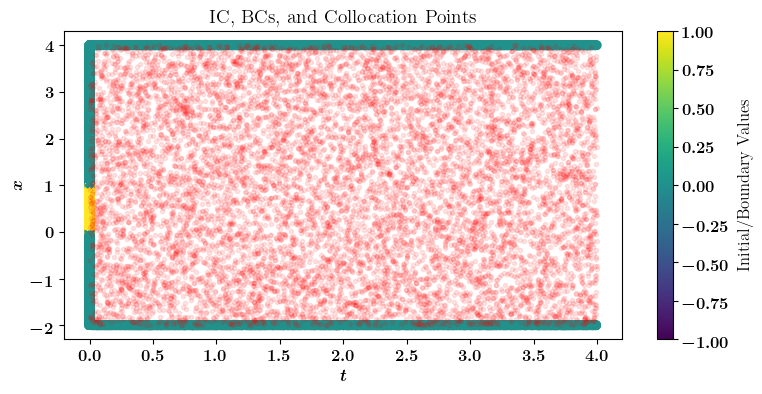

In [50]:
# Draw uniformly sampled collocation points with initial/boundary points
fig = plt.figure(figsize=(9,4))
plt.scatter(t_0, x_0, c=v_0, marker='X', vmin=-1, vmax=1)
cbar = plt.colorbar()       #This is based on the first scatter plot values
cbar.set_label('Initial/Boundary Values')
plt.scatter(t_b, x_b, c=v_b, marker='o', vmin=-1, vmax=1)
plt.scatter(t_r, x_r, c='r', marker='.', alpha=0.1)
plt.xlabel('$t$')
plt.ylabel('$x$')

plt.title('IC, BCs, and Collocation Points', fontsize = 14);

#plt.savefig('../Experiment5/Simulations/ex5.15.data1234.pdf', bbox_inches='tight', dpi=300)
#plt.show()
#plt.clf()

In [51]:
# Set up the data neural network (MLP)
def init_model(num_hidden_layers=8, num_neurons_per_layer=20):
    # Instantiate a feedforward neural network
    model = tf.keras.Sequential()

    # Input is two-dimensional (time + one spatial dimension)
    model.add(tf.keras.Input(2))

    # Introduce a scaling layer to map input to [lb, ub]
    scaling_layer = tf.keras.layers.Lambda(
                lambda x: 2.0*(x - lb)/(ub - lb) - 1.0
                )
    model.add(scaling_layer)

    # Append hidden layers
    for _ in range(num_hidden_layers):
        model.add(tf.keras.layers.Dense(num_neurons_per_layer,
            activation=tf.keras.activations.get('tanh'),
            kernel_initializer='glorot_normal'))

    # Output is one-dimensional
    model.add(tf.keras.layers.Dense(1))
    
    ### Print a summary of neural network architecture
    model.summary()
    
    return model

def get_r(model, alpha2, X_r):  
    
    # A tf.GradientTape is used to compute derivatives in TensorFlow
    with tf.GradientTape(persistent=True) as tape:
        # Split t and x to compute partial derivatives
        t, x = X_r[:, 0:1], X_r[:,1:2]

        # Variables t and x are watched during tape
        # to compute derivatives u_t and u_x
        tape.watch(t)
        tape.watch(x)

        # Determine residual 
        v = model(tf.stack([t[:,0], x[:,0]], axis=1))

        # Compute gradient v_x within the GradientTape
        # since we need second derivatives
        v_x = tape.gradient(v, x)
            
    v_t = tape.gradient(v, t)
    v_xx = tape.gradient(v_x, x)

    del tape

    return fun_r(t, x, v, v_t, v_x, v_xx, alpha2)

def compute_loss(model, alpha2, X_r, X_data, v_data):
    
    # Compute phi^r
    r = get_r(model,alpha2, X_r)
    phi_r = tf.reduce_mean(tf.square(r))
    
    # Initialize loss
    loss_res_value = phi_r
    loss_ics_value = 0.0                   
    loss_bry_value = 0.0
    loss = loss_res_value + loss_ics_value + loss_bry_value
    
    # Add phi^0 and phi^b to the loss
    for i in range(len(X_data)):
        v_pred = model(X_data[i])
        loss_ics_value += tf.reduce_mean(tf.square(v_data[i][0] - v_pred[0])) 
        loss_bry_value += tf.reduce_mean(tf.square(v_data[i][1] - v_pred[1])) 
        loss += tf.reduce_mean(tf.square(v_data[i] - v_pred))
    
    return loss_ics_value, loss_bry_value, loss_res_value, loss

def get_grad(model, alpha2, X_r, X_data, v_data):
    
    with tf.GradientTape(persistent=True) as tape:
        # This tape is for derivatives with
        # respect to trainable variables
        ##tape.watch(model.trainable_variables+[alpha2])
        tape.watch(model.trainable_variables)
        loss_ics_value, loss_bry_value, loss_res_value, loss = compute_loss(model, alpha2, X_r, X_data, v_data)

  #  g = tape.gradient(loss, model.trainable_variables)  # For a fixed alpha 
    g = tape.gradient(loss, model.trainable_variables+[alpha2]) # For a non-fixed alpha
    #g = tape.gradient(loss, model.trainable_variables.append(alpha2))
    del tape

    return loss_ics_value, loss_bry_value, loss_res_value, loss, g


In [53]:
# Initialize model u_\theta
model = init_model()

from time import time

#n_trainable = len(model.trainable_variables)

# Define one training step as a TensorFlow function to increase speed of training
@tf.function # Check this out!
def train_step():
    # Compute current loss and gradient w.r.t. parameters
    loss_ics_value, loss_bry_value, loss_res_value, loss, grad_theta = get_grad(model, alpha2, X_r, X_data, v_data)
    
    #alpha2 = tf.clip_by_value(alpha2, 1e-6, 1e-3)
    # Perform gradient descent step
    #optim.apply_gradients(zip(grad_theta, model.trainable_variables)) # For a fixed alpha
    optim.apply_gradients(zip(grad_theta, model.trainable_variables + [alpha2])) # For a non-fixed alpha
   
    #optim.apply_gradients(zip(grad_theta, model.trainable_variables.append(alpha2)))
    
    return loss_ics_value, loss_bry_value, loss_res_value, loss, alpha2

print("TensorFlow version: {}".format(tf.__version__))
print("Eager execution: {}".format(tf.executing_eagerly()))
print("GPU-numbers: {}".format(len(tf.config.list_physical_devices('GPU'))))
# get the number of logical cpu cores
n_cores = cpu_count()
# report the number of logical cpu cores
print(f'Number of Logical CPU cores: {n_cores}')
print(' ')

# Start timer
t0 = time()

for i in range(N_epoch+1):
    
    loss_ics_value, loss_bry_value, loss_res_value, loss, alpha2 = train_step() 
    
    # Append current loss to hist
    hist_ics.append(loss_ics_value.numpy()) 
    hist_bry.append(loss_bry_value.numpy())
    hist_res.append(loss_res_value.numpy()) 
    hist.append(loss.numpy())
    
    # Record the history of alpha2 values
    hist_alpha2.append(alpha2.numpy())
    
    # Output current loss after 50 iterates
    if i%1000 == 0:
        print('It {:05d}: loss_ics_value = {:10.8e}, \
              loss_bry_value = {:10.8e}, \
              loss_res_value = {:10.8e}, \
              loss = {:10.8e}, \
              alpha2 = {:10.8e}'.format(i,loss_ics_value, loss_bry_value, loss_res_value, loss, alpha2))
            
# Print computation time
print('\nComputation time: {} seconds'.format(time()-t0))

#print alpha2
print('\n alpha2 is {} '.format(alpha2.numpy()))

# Set up meshgrid 
Nt_grid = np.size(exact_t_long) ##!!! For a long time simulation betond training time exact_t
Nx_grid = np.size(exact_x_long)

tspace = tf.cast(exact_t_long, DTYPE) # Convert dtype of 'exact_t' (double tensor) to float tensor
xspace = tf.cast(exact_x_long, DTYPE)
T, X = np.meshgrid(tspace, xspace)
Xgrid = np.vstack([T.flatten(),X.flatten()]).T

# Determine predictions of v(t, x)
vpred = model(tf.cast(Xgrid,DTYPE))

# Reshape upred
V = vpred.numpy().reshape(Nx_grid,Nt_grid)
print(V.shape)

# Relative L^2 Error
relative_L2_error = []

for i in range(Nt_grid):
    error = np.linalg.norm(exact_v_long[i] - V.T[i], 2) / np.linalg.norm(exact_v_long[i], 2)
    relative_L2_error.append(error)

relative_error = np.average(relative_L2_error)

Model: "sequential_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lambda_8 (Lambda)           (None, 2)                 0         
                                                                 
 dense_72 (Dense)            (None, 20)                60        
                                                                 
 dense_73 (Dense)            (None, 20)                420       
                                                                 
 dense_74 (Dense)            (None, 20)                420       
                                                                 
 dense_75 (Dense)            (None, 20)                420       
                                                                 
 dense_76 (Dense)            (None, 20)                420       
                                                                 
 dense_77 (Dense)            (None, 20)               

In [58]:
print(tspace.shape, xspace.shape)
#print(Xgrid.shape)
#print(Xgrid[200:300,1])
print(exact_v_long.shape, V.shape)

(1201,) (600,)
(1201, 600) (600, 1201)


Text(0.5, 1.0, 'Averaged $\\epsilon(\\ell^2)$ = 0.3477')

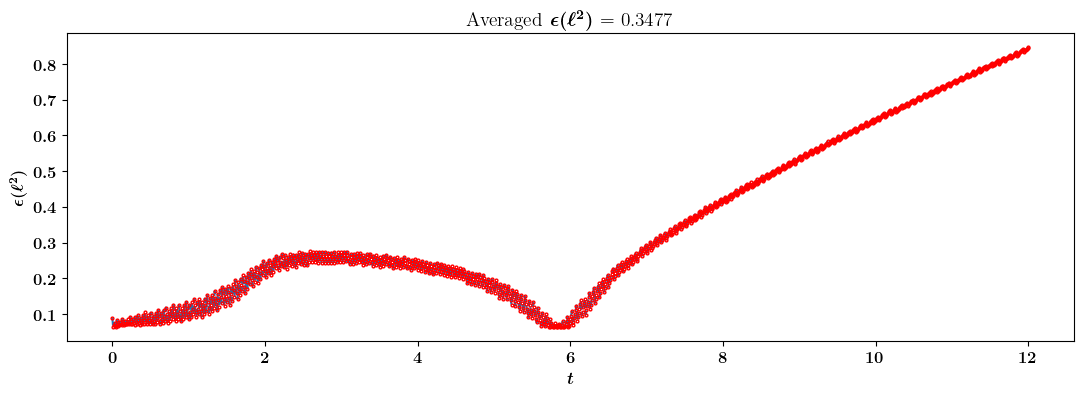

In [54]:
fig = plt.figure(figsize=(13, 4))
plt.plot(tspace, relative_L2_error, '--',)
plt.plot(tspace, relative_L2_error, 'o', color='red', fillstyle='none', markersize=2)
plt.ylabel('$\epsilon(\ell^2)$')
plt.xlabel('$t$')
plt.title('Averaged $\epsilon(\ell^2)$ = %.4f' % (relative_error), fontsize = 14)

#plt.savefig('./results/ksiam-alpha0.027-time12-rel-error.png', bbox_inches='tight', dpi=300)

#plt.show()
#plt.clf()

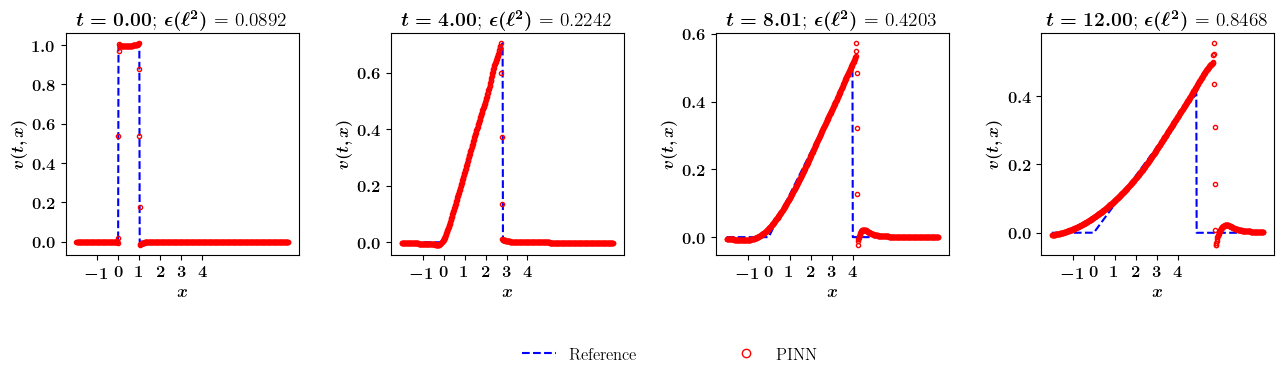

In [62]:
mid1 = int(np.floor((Nt_grid+1)/3))
mid2 = int(np.floor(2*(Nt_grid+1)/3))

fig = plt.figure(figsize=(13, 4))
plt.subplot(1, 4, 1)
#plt.plot(xspace, exact_v[0], '--', color='blue') # Whithin training time
plt.plot(xspace, exact_v_long[0], '--', color='blue') # For extrapolation after training time
plt.plot(xspace, V.T[0], 'o', color='red', fillstyle='none', markersize=3) #V.T[0] is correct but tspace number of data
#plt.plot(xspace, V[0], 'o', color='red', fillstyle='none', markersize=4)
plt.xlabel('$x$')
plt.ylabel('$v(t, x)$')
plt.xticks(np.arange(-1, 4.1, 1.0))
plt.title('$t = %.2f$; $\epsilon(\ell^2)$ = %.4f' % (tspace[0], relative_L2_error[0]), fontsize = 14)
plt.tight_layout()

plt.subplot(1,4, 2)
#plt.plot(xspace, exact_v[mid1], '--', color='blue') # Whithin training time
plt.plot(xspace, exact_v_long[mid1], '--', color='blue', label = 'Reference')
plt.plot(xspace, V.T[mid1], 'o', color='red', fillstyle='none', markersize=3) #whwn change the meshgrid number N, need to change to V.T[N/2]
plt.xlabel('$x$')
plt.ylabel('$v(t, x)$')
plt.xticks(np.arange(-1, 4.1, 1.0))
plt.legend(loc='upper left', bbox_to_anchor=(0.5, -0.35), ncol=1, frameon=False)
#plt.title('$t = %.3f$' % tspace[mid1], fontsize = 14)
plt.title('$t = %.2f$; $\epsilon(\ell^2)$ = %.4f' % (tspace[mid1], relative_L2_error[mid1]), fontsize = 14)
plt.tight_layout()

plt.subplot(1,4, 3)
##plt.plot(xspace, exact_v[mid2], '--', color='blue') # Whithin training time
plt.plot(xspace, exact_v_long[mid2], '--', color='blue')
plt.plot(xspace, V.T[mid2], 'o', color='red', fillstyle='none', markersize=3,
        label = 'PINN') #whwn change the meshgrid number N, need to change to V.T[N/2]
plt.xlabel('$x$')
plt.ylabel('$v(t, x)$')
plt.xticks(np.arange(-1, 4.1, 1.0))
plt.legend(loc='upper right', bbox_to_anchor=(0.5, -0.35), ncol=1, frameon=False,
         markerscale=2)
#plt.title('$t = %.3f$' % tspace[mid2], fontsize = 14)
plt.title('$t = %.2f$; $\epsilon(\ell^2)$ = %.4f' % (tspace[mid2], relative_L2_error[mid2]), fontsize = 14)
plt.tight_layout()

plt.subplot(1, 4, 4)
##plt.plot(xspace, exact_v[-1], '--', color='blue') # Whithin training time
plt.plot(xspace, exact_v_long[-1], '--', color='blue')
plt.plot(xspace, V.T[-1], 'o', color='red', fillstyle='none', markersize=3)
plt.xlabel('$x$')
plt.ylabel('$v(t, x)$')
plt.xticks(np.arange(-1, 4.1, 1.0))
#plt.title('$t = %.3f$' % tspace[-1], fontsize = 14)
plt.title('$t = %.2f$; $\epsilon(\ell^2)$ = %.4f' % (tspace[-1], relative_L2_error[-1]), fontsize = 14)
plt.tight_layout()

#plt.savefig('./results/ksiam-alpha0.027-time12.png', bbox_inches='tight', dpi=300)
#plt.savefig('../Experiment8/results/exact2.png', bbox_inches='tight')

#plt.show()
#plt.clf()

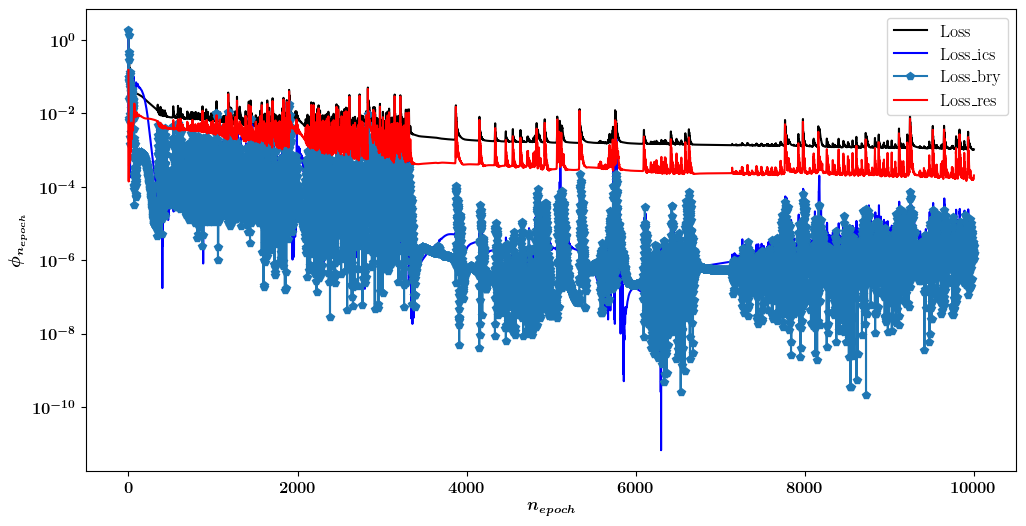

In [64]:
fig = plt.figure(figsize=(12,6))
ax = fig.add_subplot(111)
#ax.semilogy(range(len(hist)), hist,'k-', range(len(hist_ics)), hist_ics, 'b-', range(len(hist_res)), hist_res,'r-',)
ax.semilogy(range(len(hist)), hist,'k-', label="Loss")
ax.semilogy(range(len(hist_ics)), hist_ics, 'b-', label="Loss\_ics")
ax.semilogy(range(len(hist_bry)), hist_bry, 'p-', label="Loss\_bry")
ax.semilogy(range(len(hist_res)), hist_res,'r-', label="Loss\_res")
ax.legend()
ax.set_xlabel('$n_{epoch}$')
ax.set_ylabel('$\\phi_{n_{epoch}}$');
#plt.savefig('../Experiment5/Simulations/ex5.15.loss1234.pdf', bbox_inches='tight', dpi=300)

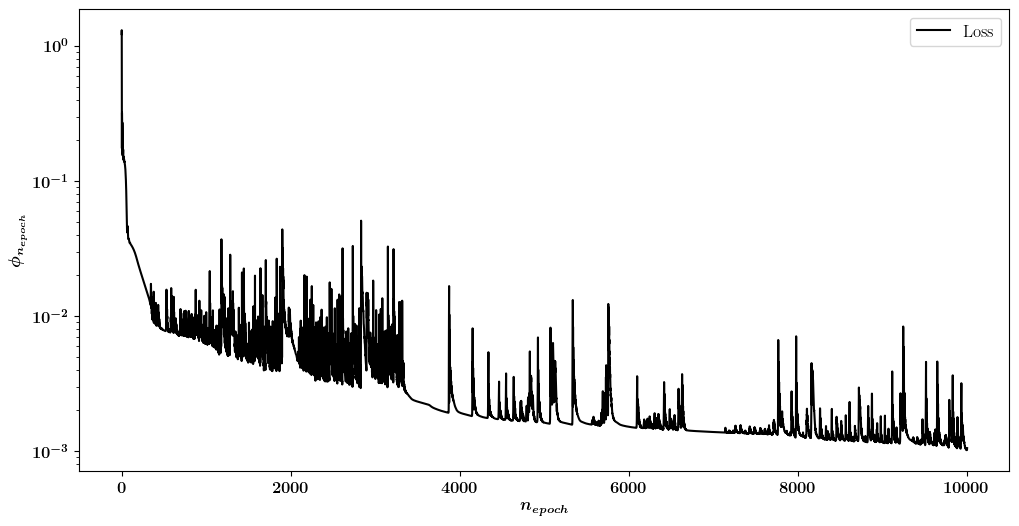

In [65]:
fig = plt.figure(figsize=(12,6))
ax = fig.add_subplot(111)
#ax.semilogy(range(len(hist)), hist,'k-', range(len(hist_ics)), hist_ics, 'b-', range(len(hist_res)), hist_res,'r-',)
ax.semilogy(range(len(hist)), hist,'k-', label="Loss")
ax.legend()
ax.set_xlabel('$n_{epoch}$')
ax.set_ylabel('$\\phi_{n_{epoch}}$');
#plt.savefig('../Experiment5/Simulations/ex5.15.losstotal1234.pdf', bbox_inches='tight', dpi=300)